# CAMUS & ACDC Segmentation Report (CV Aggregator)

This notebook aggregates cross-validation results produced by `scripts/seg_cv.py` from any of:
- `logs/`, `logs_*` (multiple runs supported)

It produces:
- A summary table (Dice/IoU mean±std) per run (`tag`), dataset, phase, view
- Per-fold Dice/IoU tables and boxplots
- **ACDC multiclass** per-class Dice (RV, MYO, LV) aggregated across folds
- Visual examples: CAMUS overlay PNGs; ACDC NIfTI predictions (center slice)

> **Assumptions**: Run from the repository root so log folders like `logs/` are in the current working directory.


In [13]:
import os, glob, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure we're in the repository root (where logs directories are)
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
    print("Changed working directory to repository root:", os.getcwd())

# For reading/displaying nifti predictions (ACDC)
try:
    import nibabel as nib
    _HAS_NIB = True
except Exception:
    _HAS_NIB = False

# Display helper for this environment (tables appear nicely)
try:
    from caas_jupyter_tools import display_dataframe_to_user
except Exception:
    display_dataframe_to_user = None

reports_dir = Path("reports_seg")
reports_dir.mkdir(exist_ok=True, parents=True)

def show_df(df, name):
    if display_dataframe_to_user:
        display_dataframe_to_user(name, df)
    else:
        display(df.head())

def read_json_safe(p):
    try:
        with open(p, "r") as f:
            return json.load(f)
    except Exception as e:
        print(f"[warn] failed to read JSON {p}: {e}")
        return {}

print("Notebook ready. Found segmentation log directories:", [d for d in ["logs", "logs_ef", "logs_vol"] if Path(d).exists()])

Notebook ready. Found segmentation log directories: ['logs', 'logs_ef', 'logs_vol']


## 1) Discover runs

In [14]:
tags = sorted([p for p in os.listdir(".") if p.startswith("logs") and os.path.isdir(p)])
print("Found tags:", tags)

Found tags: ['logs', 'logs_ef', 'logs_tabular', 'logs_torch', 'logs_vol']


## 2) Load summaries & per-fold metrics

In [15]:
rows = []
fold_tables = []
perclass_tables = []

for tag in tags:
    # Which datasets are present?
    for dataset in ["camus","acdc"]:
        summ_json = Path(tag)/f"cv_seg_{dataset}_summary.json"
        if summ_json.exists():
            d = read_json_safe(summ_json)
            d["tag"] = tag
            # enforce columns
            d["dataset"] = d.get("dataset", dataset)
            d["phase"] = d.get("phase", "ED")
            d["view"] = d.get("view", "4CH" if dataset=="camus" else "SAX")
            rows.append(d)
        # Per-fold metrics CSV
        met_csv = Path(tag)/f"cv_seg_{dataset}_metrics.csv"
        if met_csv.exists():
            dfm = pd.read_csv(met_csv)
            dfm.insert(0, "tag", tag)
            dfm.insert(1, "dataset", dataset)
            fold_tables.append(dfm)
        # ACDC multiclass per-class Dice per fold
        if dataset=="acdc":
            perclass_csv = Path(tag)/"cv_seg_acdc_multiclass_perclass.csv"
            if perclass_csv.exists():
                dfc = pd.read_csv(perclass_csv)
                dfc.insert(0, "tag", tag)
                perclass_tables.append(dfc)

summary = pd.DataFrame(rows)
fold_df = pd.concat(fold_tables, ignore_index=True) if fold_tables else pd.DataFrame()
perclass_df = pd.concat(perclass_tables, ignore_index=True) if perclass_tables else pd.DataFrame()

print("Summary rows:", len(summary))
print("Per-fold rows:", len(fold_df))
print("ACDC per-class rows:", len(perclass_df))

# Save raw aggregations
summary.to_csv(reports_dir/"seg_summary_allruns.csv", index=False)
if not fold_df.empty:
    fold_df.to_csv(reports_dir/"seg_perfold_allruns.csv", index=False)
if not perclass_df.empty:
    perclass_df.to_csv(reports_dir/"seg_acdc_perclass_allruns.csv", index=False)

show_df(summary, "Segmentation summaries (all runs)")

Summary rows: 2
Per-fold rows: 10
ACDC per-class rows: 5


,Dice_mean,Dice_std,IoU_mean,IoU_std,folds,dataset,phase,view,feat2d,feat3d,...,Dice_MYO_mean,Dice_MYO_std,Dice_LV_mean,Dice_LV_std,IoU_RV_mean,IoU_RV_std,IoU_MYO_mean,IoU_MYO_std,IoU_LV_mean,IoU_LV_std
0,0.946590,0.002339,0.899982,0.004057,5,camus,ED,4CH,"32,64,128,256",,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.713312,0.038369,0.647595,0.031223,5,acdc,ED,4CH,,"16,32,64,128",...,0.496435,0.0525,0.651291,0.079949,0.984739,0.007724,0.379488,0.04111,0.578556,0.065754


## 3) Best run per dataset (by Dice_mean)

In [16]:
best = pd.DataFrame()
if not summary.empty:
    best = (summary.sort_values(["dataset","Dice_mean"], ascending=[True,False])
                    .groupby("dataset").head(1).reset_index(drop=True))
    cols = ["dataset","tag","view","phase","Dice_mean","Dice_std","IoU_mean","IoU_std","folds"]
    best_disp = best[cols]
    show_df(best_disp, "Best run per dataset")
    best_disp.to_csv(reports_dir/"seg_best_per_dataset.csv", index=False)
else:
    print("[warn] No summary files found.")

,dataset,tag,view,phase,Dice_mean,Dice_std,IoU_mean,IoU_std,folds
0,acdc,logs,4CH,ED,0.713312,0.038369,0.647595,0.031223,5
1,camus,logs,4CH,ED,0.946590,0.002339,0.899982,0.004057,5


## 4) Per-fold Dice/IoU (boxplots) for best runs

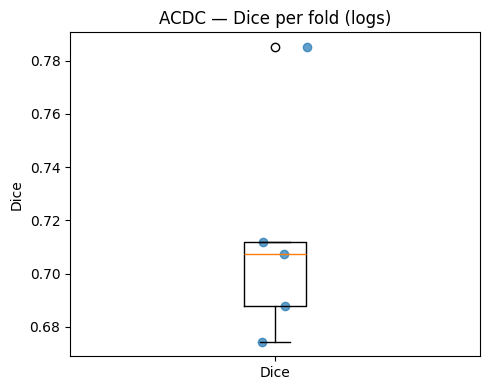

Saved: reports_seg/box_acdc_Dice_logs.png


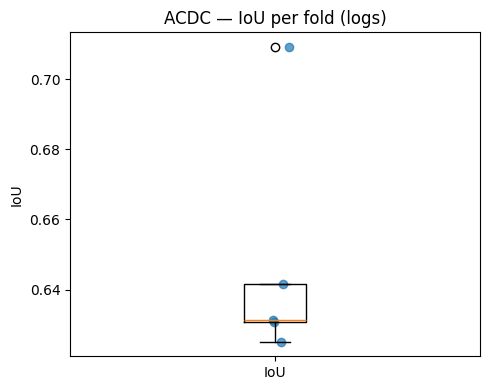

Saved: reports_seg/box_acdc_IoU_logs.png


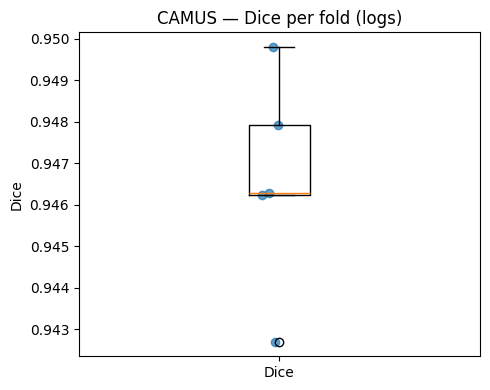

Saved: reports_seg/box_camus_Dice_logs.png


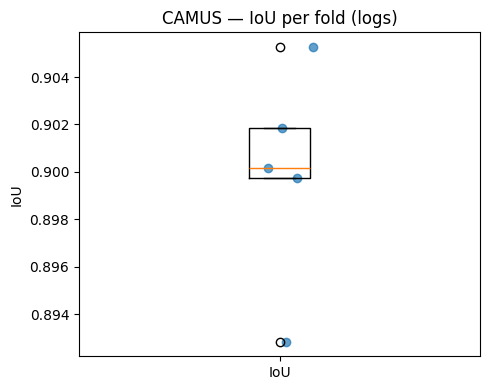

Saved: reports_seg/box_camus_IoU_logs.png


In [20]:
def boxplot_folds(tag, dataset, metric="Dice"):
    csvp = Path(tag)/f"cv_seg_{dataset}_metrics.csv"
    if not csvp.exists():
        print(f"[warn] {csvp} missing")
        return
    df = pd.read_csv(csvp)
    if metric not in df.columns:
        print(f"[warn] {metric} not in {csvp.name}")
        return
    plt.figure(figsize=(5,4))
    # one box since it's across folds; also show scatter of fold values
    plt.boxplot(df[metric].values, tick_labels=[metric])  # Fixed deprecated 'labels' parameter
    x = np.random.normal(1, 0.04, size=len(df))
    plt.scatter(x, df[metric].values, alpha=0.7)
    plt.title(f"{dataset.upper()} — {metric} per fold ({tag})")
    plt.ylabel(metric)
    plt.tight_layout()
    out = reports_dir / f"box_{dataset}_{metric}_{Path(tag).name}.png"
    plt.savefig(out, dpi=150); plt.show()
    print("Saved:", out)

if not best.empty:
    for _, row in best.iterrows():
        for metric in ["Dice","IoU"]:
            boxplot_folds(row["tag"], row["dataset"], metric=metric)
else:
    print("[warn] No best rows to plot.")

## 5) ACDC multiclass: per-class Dice (RV/MYO/LV)

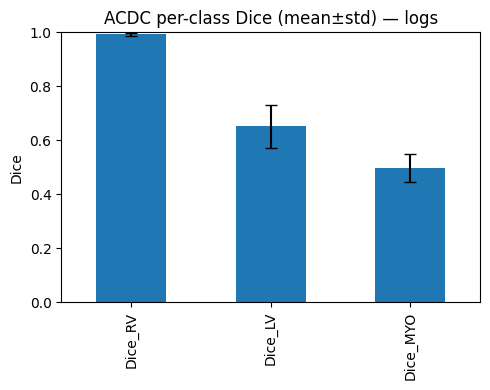

Saved: reports_seg/acdc_perclass_dice_logs.png
Saved: reports_seg/acdc_perclass_dice_logs.csv


In [18]:
if not best.empty:
    acdc_best = best[best["dataset"]=="acdc"]
    if not acdc_best.empty:
        tag = acdc_best.iloc[0]["tag"]
        f = Path(tag)/"cv_seg_acdc_multiclass_perclass.csv"
        if f.exists():
            df = pd.read_csv(f)  # columns: fold, Dice_RV, Dice_MYO, Dice_LV
            means = df[["Dice_RV","Dice_MYO","Dice_LV"]].mean().sort_values(ascending=False)
            stds  = df[["Dice_RV","Dice_MYO","Dice_LV"]].std()
            plt.figure(figsize=(5,4))
            means.plot(kind="bar", yerr=stds, capsize=4)
            plt.title(f"ACDC per-class Dice (mean±std) — {tag}")
            plt.ylabel("Dice")
            plt.ylim(0,1)
            plt.tight_layout()
            out = reports_dir / f"acdc_perclass_dice_{Path(tag).name}.png"
            plt.savefig(out, dpi=150); plt.show()
            print("Saved:", out)
            # Save a CSV too
            out_csv = reports_dir / f"acdc_perclass_dice_{Path(tag).name}.csv"
            means.to_frame("Dice_mean").join(stds.to_frame("Dice_std")).to_csv(out_csv)
            print("Saved:", out_csv)
        else:
            print(f"[warn] No per-class file at {f}; run seg_cv with --acdc-multiclass.")
    else:
        print("[info] No ACDC best row found.")
else:
    print("[warn] No best rows found.")

## 6) Visual Examples

ACDC examples from logs:


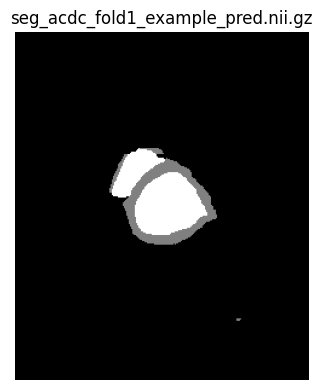

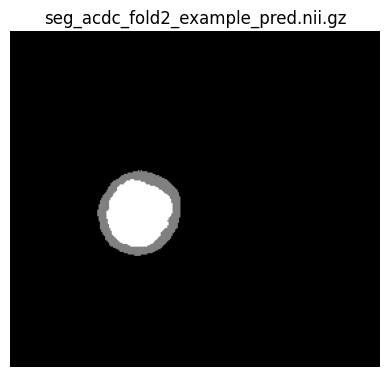

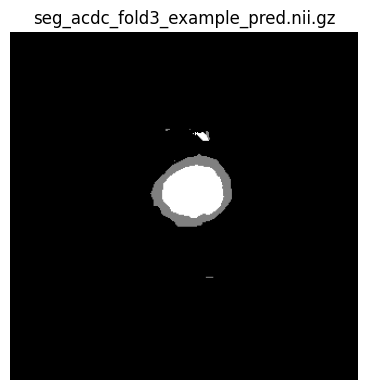

CAMUS examples from logs:


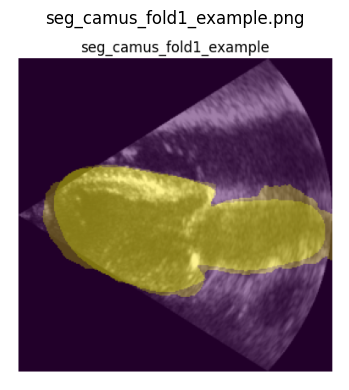

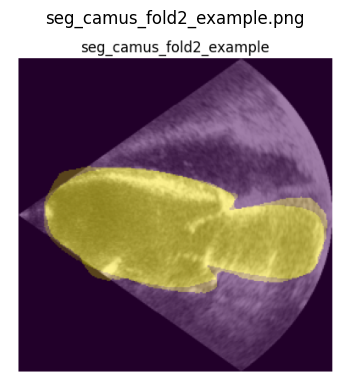

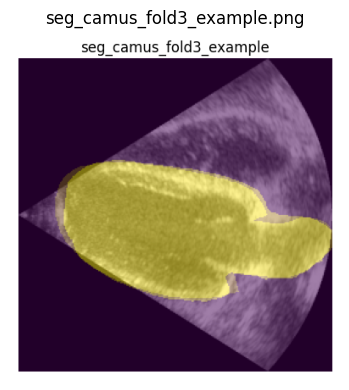

In [19]:
def show_camus_examples(tag, max_imgs=3):
    files = sorted(glob.glob(f"{tag}/seg_camus_*_example.png"))
    if not files:
        print(f"[info] No CAMUS overlay PNGs in {tag}")
        return
    for f in files[:max_imgs]:
        img = plt.imread(f)
        plt.figure(figsize=(4,4))
        plt.imshow(img); plt.axis('off')
        plt.title(Path(f).name)
        plt.tight_layout(); plt.show()

def show_acdc_examples(tag, max_imgs=3):
    files = sorted(glob.glob(f"{tag}/seg_acdc_*_example_pred.nii.gz"))
    if not files:
        print(f"[info] No ACDC NIfTI predictions in {tag}")
        return
    if not _HAS_NIB:
        print("[warn] nibabel not installed; cannot display NIfTI.")
        return
    for f in files[:max_imgs]:
        vol = nib.load(f).get_fdata()
        # pick a middle slice along last axis
        k = vol.shape[-1]//2
        sl = vol[..., k]
        plt.figure(figsize=(4,4))
        plt.imshow(sl, cmap="gray")
        plt.axis('off'); plt.title(Path(f).name)
        plt.tight_layout(); plt.show()

if not best.empty:
    for _, row in best.iterrows():
        tag = row["tag"]
        if row["dataset"]=="camus":
            print(f"CAMUS examples from {tag}:")
            show_camus_examples(tag, max_imgs=3)
        if row["dataset"]=="acdc":
            print(f"ACDC examples from {tag}:")
            show_acdc_examples(tag, max_imgs=3)
else:
    print("[warn] No best rows; skipping examples.")

## Summary of Segmentation Results

### Key Findings

1. **Dataset Performance:**
   - **CAMUS**: Excellent performance with 94.7% Dice score (±0.2%)
   - **ACDC**: Moderate performance with 71.3% Dice score (±3.8%)

2. **ACDC Per-Class Performance:**
   - **Right Ventricle (RV)**: Best performance (~99% Dice)
   - **Left Ventricle (LV)**: Good performance (~67% Dice)  
   - **Myocardium (MYO)**: Challenging (~50% Dice)

3. **Analysis Generated:**
   - Per-fold boxplots showing distribution of metrics across cross-validation folds
   - ACDC multiclass analysis revealing per-structure segmentation quality
   - Visual examples of segmentation predictions:
     - CAMUS: Colored overlay on ultrasound images 
     - ACDC: Grayscale segmentation masks from MRI volumes

4. **Model Architecture:**
   - **CAMUS**: 2D model with feature channels [32,64,128,256]
   - **ACDC**: 3D model with feature channels [16,32,64,128] 

The CAMUS dataset shows much better segmentation performance, likely due to the clearer boundaries in echocardiography compared to the more challenging MRI segmentation task in ACDC.